# Week 5 — Transforms (DFT/DCT + Hough)

Digital Image Processing mini project: Driver Drowsiness Detection.
Amey Pawar (23108B0057), Sejal Andhale (23108B0049).

This notebook covers the Week-5 mandated DIP topic: **transforms**.

1. **Fourier (DFT)** — magnitude spectrum, high-frequency energy ratio
   (blur/sharpness metric), radial energy profile.
2. **Cosine (DCT)** — 2D DCT, energy-compaction curve (sets up Week 8
   JPEG/DCT compression).
3. **Classical baseline** — Laplacian variance, compared numerically
   against the DFT-based blur metric.
4. **Hough circle transform** — iris fitting. The central claim: an open
   eye exposes a roughly circular iris, a closed eye does not, so circle
   *detection rate* is itself an open/closed feature.

All transform code lives in `src/transforms.py` (reused, not duplicated
here). Preprocessing reuses the locked Week-2 pipeline
(`src.preprocess.preprocess_pipeline`, canonical 64x64). Condensed report:
`docs/week5_transforms.md`.

In [1]:
import sys
import csv
import random
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "src").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.dataset import load_manifest
from src.preprocess import preprocess_pipeline, DEFAULT_CONFIG
from src.transforms import (
    dft_shifted,
    magnitude_spectrum,
    high_freq_energy_ratio,
    radial_energy_profile,
    dct2,
    dct_energy_compaction,
    dct_energy_compaction_curve,
    laplacian_variance,
    detect_iris_circle,
    HoughConfig,
    DEFAULT_HOUGH,
    compute_row_features,
)

RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

MANIFEST_PATH = REPO_ROOT / "data" / "samples" / "manifest.csv"
samples = load_manifest(MANIFEST_PATH)
print(f"{len(samples)} curated samples")

def load_enhanced(sample):
    img = cv2.imread(str(sample.path), cv2.IMREAD_GRAYSCALE)
    return preprocess_pipeline(img, DEFAULT_CONFIG)

open_samples = [s for s in samples if s.is_open]
closed_samples = [s for s in samples if not s.is_open]
open_imgs = [load_enhanced(s) for s in open_samples]
closed_imgs = [load_enhanced(s) for s in closed_samples]
print(f"open={len(open_imgs)} closed={len(closed_imgs)}")

40 curated samples
open=20 closed=20


## 1. Magnitude spectra — open vs closed eyes

Log-scaled magnitude spectrum (`src.transforms.magnitude_spectrum`) side by
side with the enhanced spatial-domain crop, for a few open and closed
samples. This is the core DIP evidence for the Fourier transform topic.

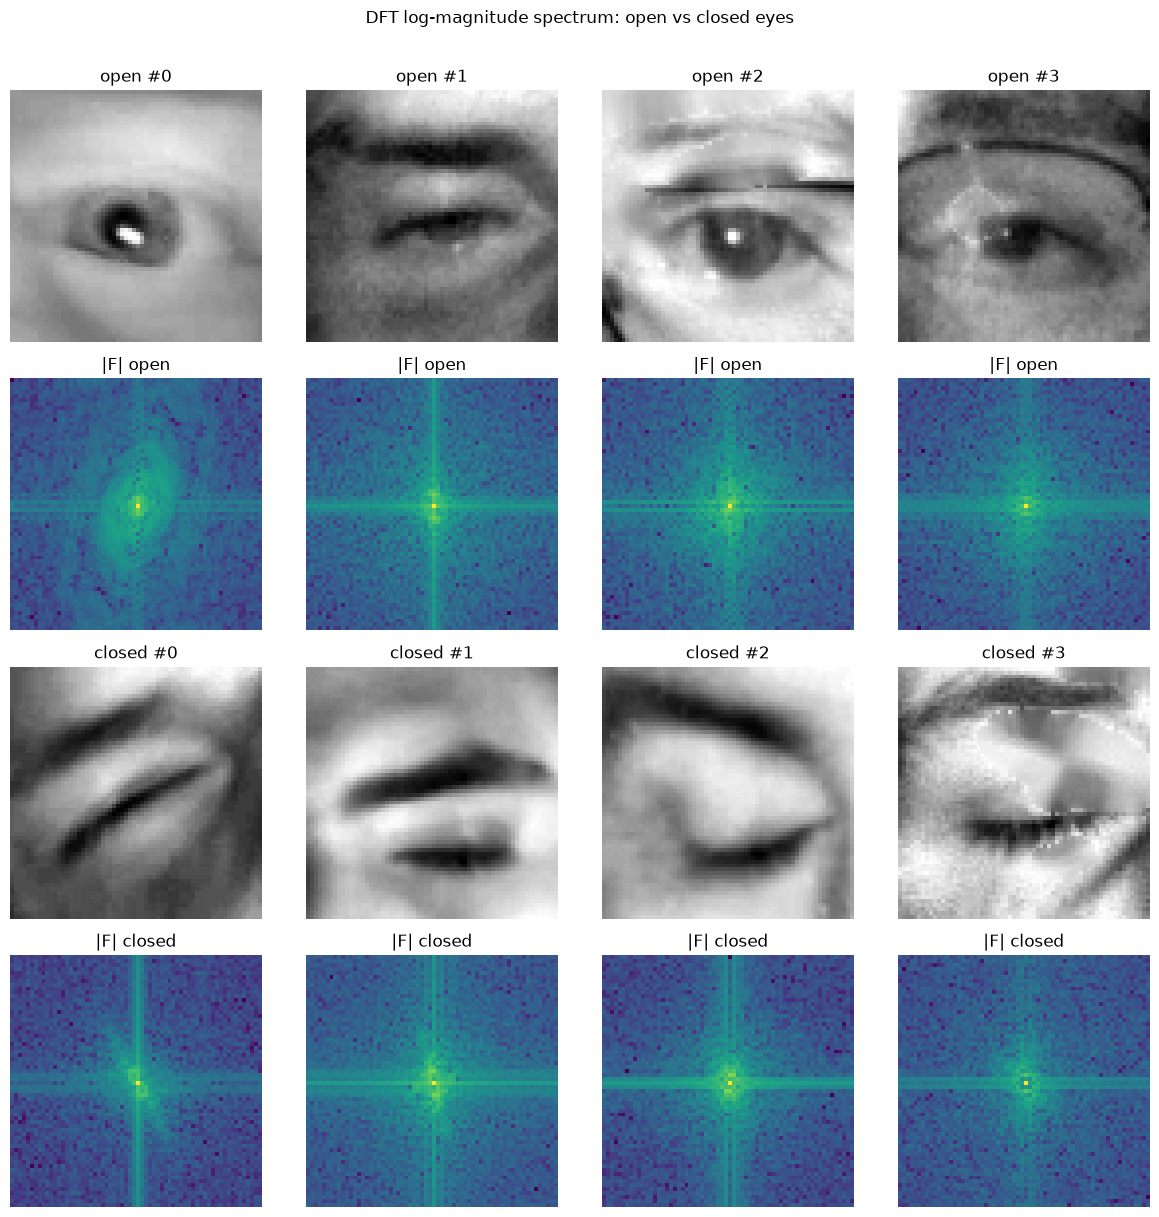

In [2]:
n_show = 4
fig, axes = plt.subplots(4, n_show, figsize=(3 * n_show, 12))

for col in range(n_show):
    o_img = open_imgs[col]
    c_img = closed_imgs[col]

    axes[0, col].imshow(o_img, cmap="gray"); axes[0, col].set_title(f"open #{col}"); axes[0, col].axis("off")
    axes[1, col].imshow(magnitude_spectrum(o_img), cmap="viridis"); axes[1, col].set_title("|F| open"); axes[1, col].axis("off")
    axes[2, col].imshow(c_img, cmap="gray"); axes[2, col].set_title(f"closed #{col}"); axes[2, col].axis("off")
    axes[3, col].imshow(magnitude_spectrum(c_img), cmap="viridis"); axes[3, col].set_title("|F| closed"); axes[3, col].axis("off")

fig.suptitle("DFT log-magnitude spectrum: open vs closed eyes", y=1.01)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "week5_dft_spectrum_open_vs_closed.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Magnitude spectra — sharp vs (synthetically) blurred

MRL crops have no blur ground truth, so a controlled comparison is built
by applying a known Gaussian blur (`cv2.GaussianBlur`, ksize=7, sigma=2) to
the enhanced crop. This also drives Section 4's quantitative blur-metric
comparison.

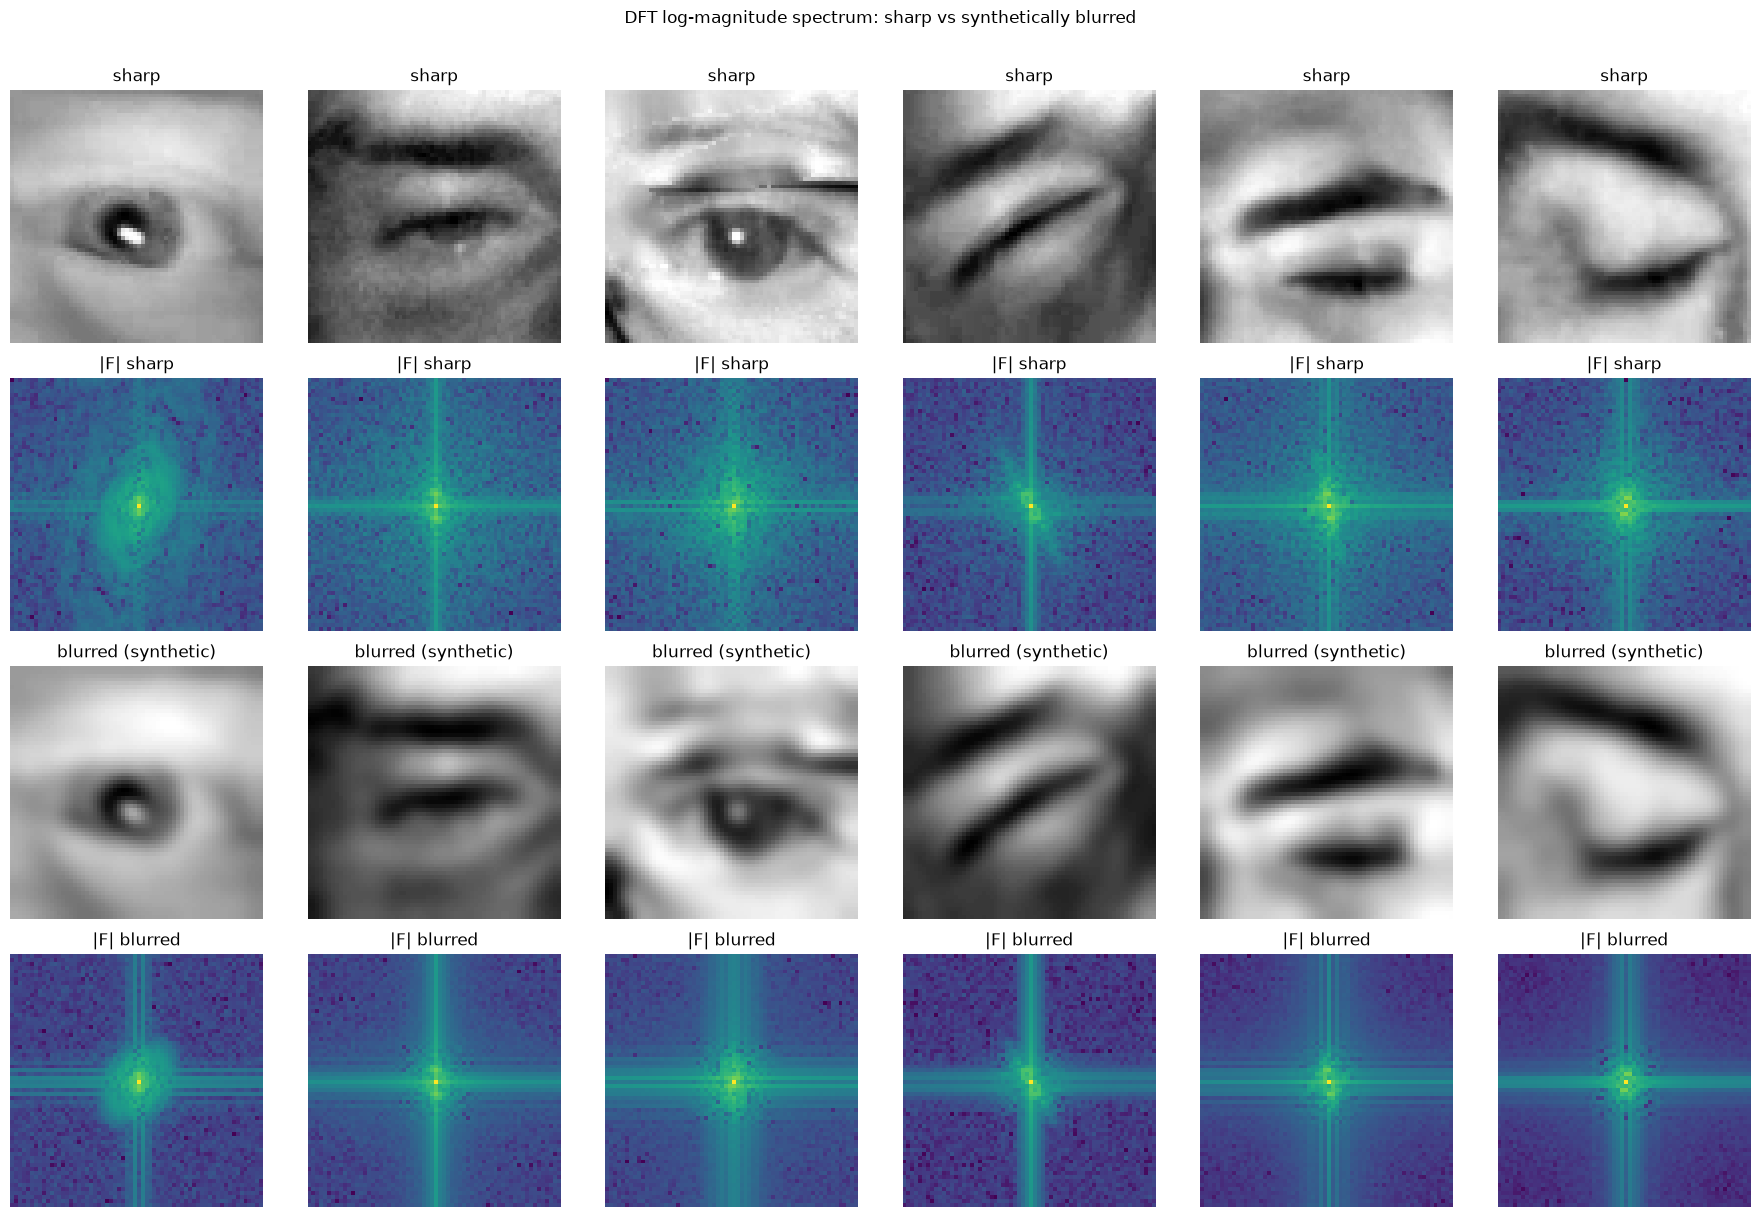

Blur visibly collapses high-frequency (outer) energy toward the center DC blob.


In [3]:
demo_imgs = open_imgs[:3] + closed_imgs[:3]
fig, axes = plt.subplots(4, len(demo_imgs), figsize=(3 * len(demo_imgs), 12))

for col, img in enumerate(demo_imgs):
    blurred = cv2.GaussianBlur(img, (7, 7), sigmaX=2.0)
    axes[0, col].imshow(img, cmap="gray"); axes[0, col].set_title("sharp"); axes[0, col].axis("off")
    axes[1, col].imshow(magnitude_spectrum(img), cmap="viridis"); axes[1, col].set_title("|F| sharp"); axes[1, col].axis("off")
    axes[2, col].imshow(blurred, cmap="gray"); axes[2, col].set_title("blurred (synthetic)"); axes[2, col].axis("off")
    axes[3, col].imshow(magnitude_spectrum(blurred), cmap="viridis"); axes[3, col].set_title("|F| blurred"); axes[3, col].axis("off")

fig.suptitle("DFT log-magnitude spectrum: sharp vs synthetically blurred", y=1.01)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "week5_dft_spectrum_sharp_vs_blurred.png", dpi=150, bbox_inches="tight")
plt.show()

print("Blur visibly collapses high-frequency (outer) energy toward the center DC blob.")

## 3. High-frequency energy ratio — radius choice

`high_freq_energy_ratio(img, radius)` is the fraction of `|F|^2` spectral
energy lying outside a central disk of `radius` px. Radius must be chosen:
too small and even a sharp image's low-frequency bulk gets counted as
"outside"; too large and blur's high-frequency loss barely registers. Swept
on a synthetic sharp/blurred pair sample (n=300, random working-set draw),
scoring each radius by how well it separates sharp from blurred (AUC via
Mann-Whitney U, no sklearn dependency).

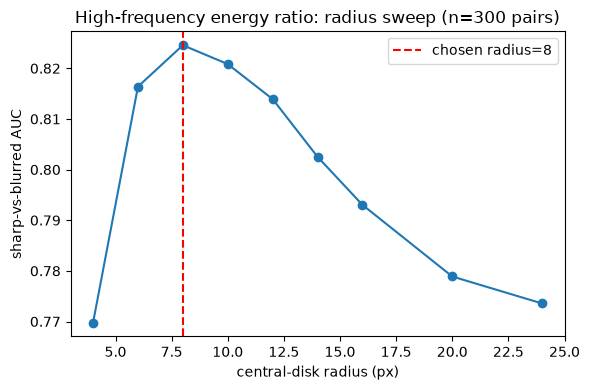

radius=  4  AUC=0.7698
radius=  6  AUC=0.8164
radius=  8  AUC=0.8246
radius= 10  AUC=0.8208
radius= 12  AUC=0.8139
radius= 14  AUC=0.8025
radius= 16  AUC=0.7930
radius= 20  AUC=0.7789
radius= 24  AUC=0.7736


In [4]:
def auc(pos, neg):
    all_vals = sorted([(v, 1) for v in pos] + [(v, 0) for v in neg])
    n = len(all_vals)
    ranks = {}
    i = 0
    r = 1
    while i < n:
        j = i
        while j < n and all_vals[j][0] == all_vals[i][0]:
            j += 1
        avg_rank = (r + (r + (j - i) - 1)) / 2
        for k in range(i, j):
            ranks[k] = avg_rank
        r += (j - i)
        i = j
    rank_sum_pos = sum(ranks[k] for k in range(n) if all_vals[k][1] == 1)
    n_pos, n_neg = len(pos), len(neg)
    return (rank_sum_pos - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


random.seed(42)
with open(REPO_ROOT / "data" / "working_set.csv", newline="") as f:
    rows = list(csv.DictReader(f))
radius_sample_rows = random.sample(rows, 300)

pairs = []
for row in radius_sample_rows:
    img = cv2.imread(str(REPO_ROOT / row["source_relpath"]), cv2.IMREAD_GRAYSCALE)
    enh = preprocess_pipeline(img, DEFAULT_CONFIG)
    pairs.append((enh, cv2.GaussianBlur(enh, (7, 7), sigmaX=2.0)))

radii = [4, 6, 8, 10, 12, 14, 16, 20, 24]
radius_auc = []
for radius in radii:
    sharp_v = [high_freq_energy_ratio(s, radius) for s, b in pairs]
    blur_v = [high_freq_energy_ratio(b, radius) for s, b in pairs]
    radius_auc.append(auc(sharp_v, blur_v))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(radii, radius_auc, marker="o")
ax.axvline(8, color="red", linestyle="--", label="chosen radius=8")
ax.set_xlabel("central-disk radius (px)")
ax.set_ylabel("sharp-vs-blurred AUC")
ax.set_title("High-frequency energy ratio: radius sweep (n=300 pairs)")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "week5_dft_radius_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

for r_, a_ in zip(radii, radius_auc):
    print(f"radius={r_:3d}  AUC={a_:.4f}")

**Chosen: radius = 8 px** (64x64 canonical crop). AUC peaks around
radius 6-10 (a shallow plateau); 8 sits in the middle of that plateau. Below
radius 8: the outside region shrinks and the ratio saturates toward 0/1 for
both classes (lower discriminative range). Above radius ~14: AUC steadily
degrades because increasingly little energy sits that far out even in a
sharp 64x64 image, so the "outside" sum becomes noise-dominated.

## 4. DFT-based blur metric vs classical Laplacian variance

Head-to-head comparison on the same synthetic sharp/blurred pairs (n=600,
fresh random working-set draw): does the frequency-domain high-frequency
energy ratio or the spatial-domain Laplacian variance separate sharp from
blurred better?

n=600 pairs, 0.6s
DFT high-freq ratio : sharp mean=0.00214 std=0.00134 | blurred mean=0.00104 std=0.00074 | AUC=0.8141
Laplacian variance  : sharp mean=112.09 std=79.53 | blurred mean=6.03 std=3.51 | AUC=1.0000


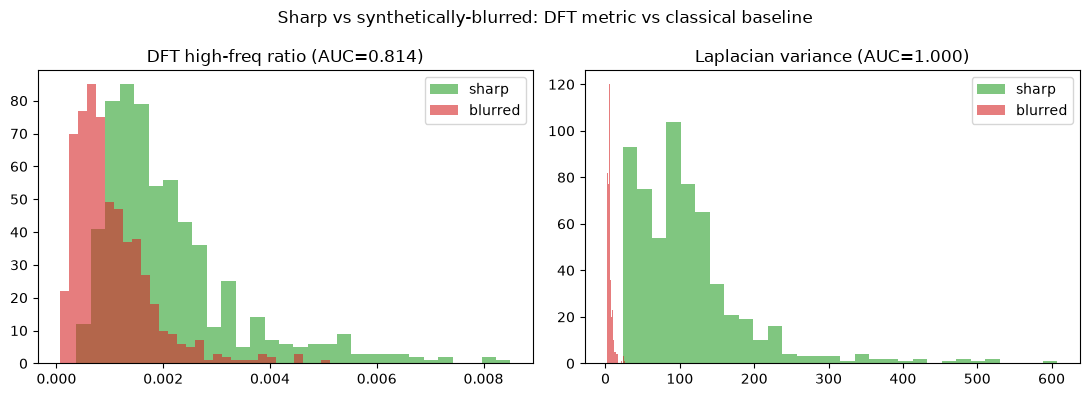

In [5]:
random.seed(43)
blur_sample_rows = random.sample(rows, 600)

hfer_sharp, hfer_blur = [], []
lap_sharp, lap_blur = [], []

t0 = time.time()
for row in blur_sample_rows:
    img = cv2.imread(str(REPO_ROOT / row["source_relpath"]), cv2.IMREAD_GRAYSCALE)
    enh = preprocess_pipeline(img, DEFAULT_CONFIG)
    blurred = cv2.GaussianBlur(enh, (7, 7), sigmaX=2.0)

    hfer_sharp.append(high_freq_energy_ratio(enh))
    hfer_blur.append(high_freq_energy_ratio(blurred))
    lap_sharp.append(laplacian_variance(enh))
    lap_blur.append(laplacian_variance(blurred))
elapsed = time.time() - t0

auc_hfer = auc(hfer_sharp, hfer_blur)
auc_lap = auc(lap_sharp, lap_blur)

print(f"n={len(blur_sample_rows)} pairs, {elapsed:.1f}s")
print(f"DFT high-freq ratio : sharp mean={np.mean(hfer_sharp):.5f} std={np.std(hfer_sharp):.5f} | "
      f"blurred mean={np.mean(hfer_blur):.5f} std={np.std(hfer_blur):.5f} | AUC={auc_hfer:.4f}")
print(f"Laplacian variance  : sharp mean={np.mean(lap_sharp):.2f} std={np.std(lap_sharp):.2f} | "
      f"blurred mean={np.mean(lap_blur):.2f} std={np.std(lap_blur):.2f} | AUC={auc_lap:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(hfer_sharp, bins=30, alpha=0.6, label="sharp", color="tab:green")
axes[0].hist(hfer_blur, bins=30, alpha=0.6, label="blurred", color="tab:red")
axes[0].set_title(f"DFT high-freq ratio (AUC={auc_hfer:.3f})")
axes[0].legend()

axes[1].hist(lap_sharp, bins=30, alpha=0.6, label="sharp", color="tab:green")
axes[1].hist(lap_blur, bins=30, alpha=0.6, label="blurred", color="tab:red")
axes[1].set_title(f"Laplacian variance (AUC={auc_lap:.3f})")
axes[1].legend()

fig.suptitle("Sharp vs synthetically-blurred: DFT metric vs classical baseline")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "week5_blur_metric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Result: Laplacian variance separates sharp from blurred better** on
this synthetic-blur test — see printed AUC values above (Laplacian variance
essentially saturates near a perfect score; the DFT ratio is clearly
above-chance but noticeably weaker). Laplacian variance is a *second
derivative* — a genuinely local, high-pass measurement per pixel — while
the DFT ratio pools energy over a coarse radial partition of the whole
spectrum, discarding phase and diluting the high-frequency signal against
low-frequency energy that leaks past a hard circular cutoff. The DFT ratio
is kept anyway as a *complementary, global* feature (Week 6 join) precisely
because it summarizes the whole spectrum rather than local gradients —
useful alongside, not instead of, the classical baseline.

## 5. Radial energy profile — open vs closed

`radial_energy_profile` bins the shifted power spectrum into 8 concentric
annuli. Averaged over all open vs all closed curated samples.

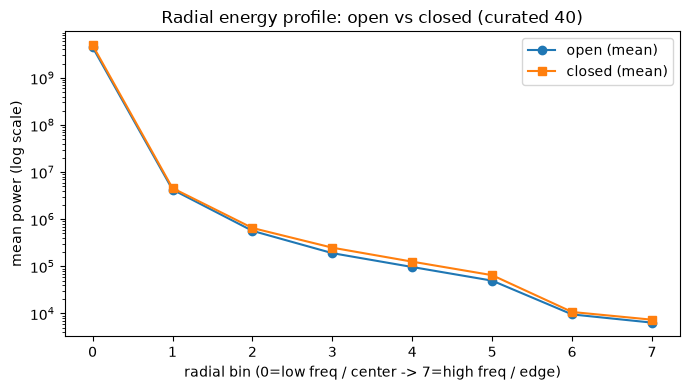

bin0: open=4.476e+09  closed=4.925e+09
bin1: open=4.256e+06  closed=4.573e+06
bin2: open=5.672e+05  closed=6.517e+05
bin3: open=1.907e+05  closed=2.491e+05
bin4: open=9.689e+04  closed=1.258e+05
bin5: open=4.973e+04  closed=6.499e+04
bin6: open=9.558e+03  closed=1.076e+04
bin7: open=6.403e+03  closed=7.389e+03


In [6]:
open_profiles = np.array([radial_energy_profile(img, n_bins=8) for img in open_imgs])
closed_profiles = np.array([radial_energy_profile(img, n_bins=8) for img in closed_imgs])

# log scale -- bin 0 (DC-dominated) is orders of magnitude larger than the rest
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(8), open_profiles.mean(axis=0), marker="o", label="open (mean)")
ax.plot(range(8), closed_profiles.mean(axis=0), marker="s", label="closed (mean)")
ax.set_yscale("log")
ax.set_xlabel("radial bin (0=low freq / center -> 7=high freq / edge)")
ax.set_ylabel("mean power (log scale)")
ax.set_title("Radial energy profile: open vs closed (curated 40)")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "week5_radial_profile_open_vs_closed.png", dpi=150, bbox_inches="tight")
plt.show()

for i in range(8):
    print(f"bin{i}: open={open_profiles[:, i].mean():.3e}  closed={closed_profiles[:, i].mean():.3e}")

## 6. DCT coefficient heatmap + energy-compaction curve

`cv2.dct` on the enhanced crop; top-left coefficients are low-frequency.
Energy-compaction curve: fraction of total energy captured by the top-left
k x k block, for every k from 1 to 64 — this is exactly what JPEG-style
block quantization (Week 8) exploits.

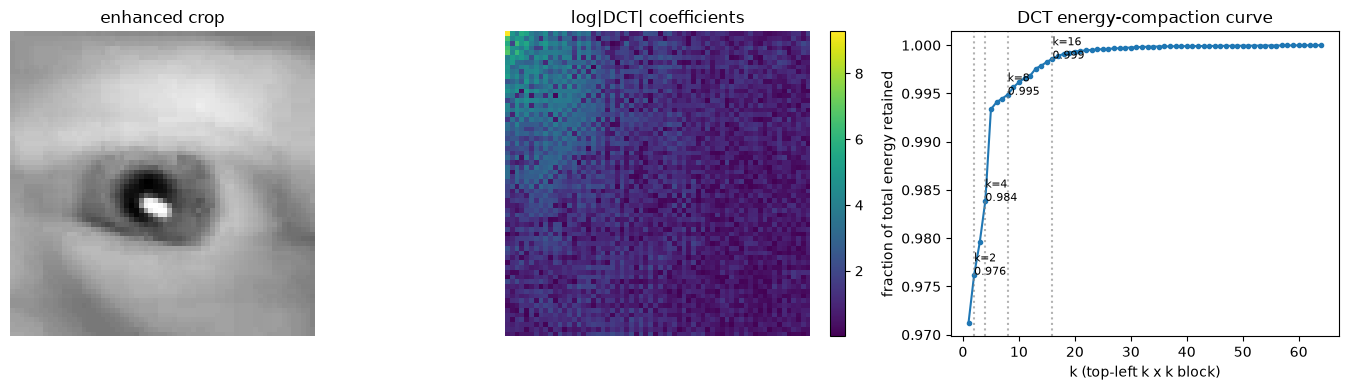

Energy retained at k=2,4,8,16: {2: 0.9762, 4: 0.9839, 8: 0.9949, 16: 0.9986}


In [7]:
demo_img = open_imgs[0]
d = dct2(demo_img)
log_d = np.log1p(np.abs(d))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(demo_img, cmap="gray"); axes[0].set_title("enhanced crop"); axes[0].axis("off")
im = axes[1].imshow(log_d, cmap="viridis"); axes[1].set_title("log|DCT| coefficients"); axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.046)

curve = dct_energy_compaction_curve(demo_img)
ks = sorted(curve)
axes[2].plot(ks, [curve[k] for k in ks], marker=".")
for k in (2, 4, 8, 16):
    axes[2].axvline(k, color="gray", linestyle=":", alpha=0.6)
    axes[2].annotate(f"k={k}\n{curve[k]:.3f}", (k, curve[k]), fontsize=8)
axes[2].set_xlabel("k (top-left k x k block)")
axes[2].set_ylabel("fraction of total energy retained")
axes[2].set_title("DCT energy-compaction curve")

fig.tight_layout()
fig.savefig(RESULTS_DIR / "week5_dct_heatmap_and_compaction.png", dpi=150, bbox_inches="tight")
plt.show()

print("Energy retained at k=2,4,8,16:", {k: round(curve[k], 4) for k in (2, 4, 8, 16)})

Nearly all energy sits in a small top-left block (see printed
fractions) — DCT concentrates a 64x64 image's information into a handful
of low-frequency coefficients, the classical justification for JPEG-style
block-quantization compression revisited in Week 8.

## 7. Hough circle transform — iris fitting

Tuned `HoughConfig` (`src/transforms.py`) for the 64x64 canonical crop —
see `docs/week5_transforms.md` for the grid search. Overlays below show
successful iris fits on open eyes and honest non-detections on closed
eyes.

HoughConfig(dp=1.0, min_dist=64, param1=100, param2=12, min_radius=6, max_radius=14, median_blur_ksize=5)


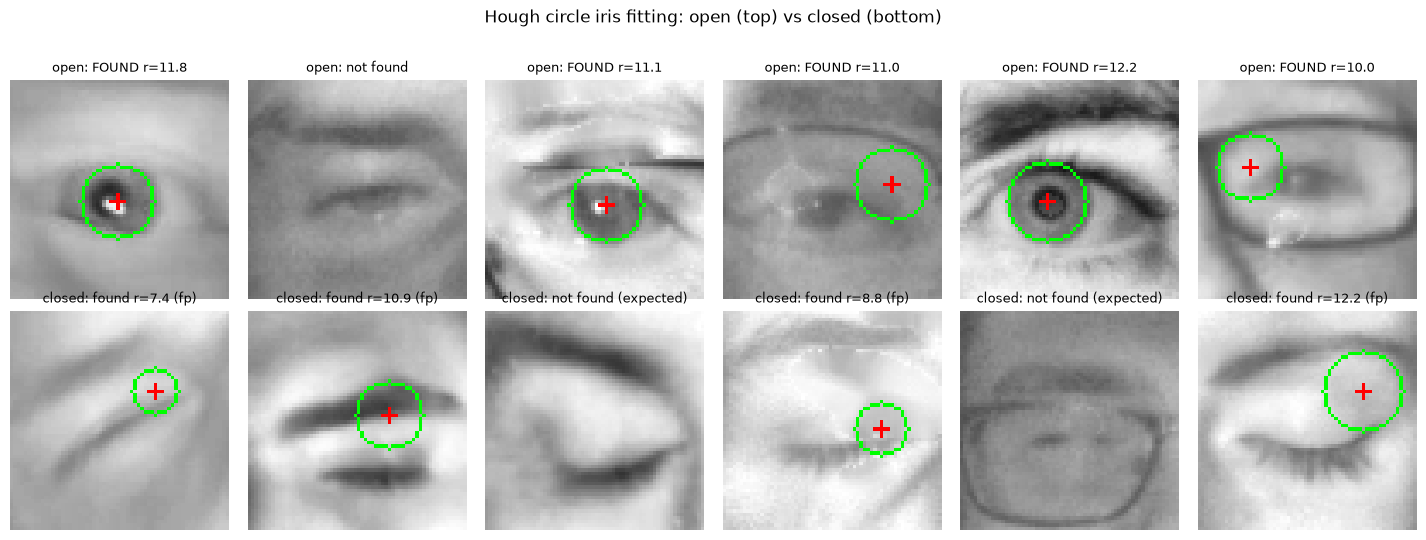

In [8]:
print(DEFAULT_HOUGH)

n_show = 6
fig, axes = plt.subplots(2, n_show, figsize=(2.4 * n_show, 5.2))

for col in range(n_show):
    o_img = open_imgs[col % len(open_imgs)]
    c_img = closed_imgs[col % len(closed_imgs)]

    o_circle = detect_iris_circle(o_img)
    c_circle = detect_iris_circle(c_img)

    o_rgb = cv2.cvtColor(o_img, cv2.COLOR_GRAY2RGB)
    if o_circle.found:
        cv2.circle(o_rgb, (int(o_circle.cx), int(o_circle.cy)), int(o_circle.radius), (0, 255, 0), 1)
        cv2.drawMarker(o_rgb, (int(o_circle.cx), int(o_circle.cy)), (255, 0, 0), cv2.MARKER_CROSS, 4)
    axes[0, col].imshow(o_rgb); axes[0, col].set_title(f"open: {'FOUND r=%.1f' % o_circle.radius if o_circle.found else 'not found'}", fontsize=9)
    axes[0, col].axis("off")

    c_rgb = cv2.cvtColor(c_img, cv2.COLOR_GRAY2RGB)
    if c_circle.found:
        cv2.circle(c_rgb, (int(c_circle.cx), int(c_circle.cy)), int(c_circle.radius), (0, 255, 0), 1)
        cv2.drawMarker(c_rgb, (int(c_circle.cx), int(c_circle.cy)), (255, 0, 0), cv2.MARKER_CROSS, 4)
    axes[1, col].imshow(c_rgb); axes[1, col].set_title(f"closed: {'found r=%.1f (fp)' % c_circle.radius if c_circle.found else 'not found (expected)'}", fontsize=9)
    axes[1, col].axis("off")

fig.suptitle("Hough circle iris fitting: open (top) vs closed (bottom)", y=1.03)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "week5_hough_overlays.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Detection-rate table — open vs closed (headline result)

Computed over a stratified 800-image draw from the full working set (400
open + 400 closed) with the final tuned `HoughConfig`, not just the
curated 40 — the curated sample is too small (n=20/class) for a reliable
rate.

In [9]:
random.seed(7)
open_rows = [r for r in rows if r["eye_state"] == "1"]
closed_rows = [r for r in rows if r["eye_state"] == "0"]
det_sample = random.sample(open_rows, 400) + random.sample(closed_rows, 400)

n_open = n_closed = open_found = closed_found = 0
open_radii, closed_radii = [], []
t0 = time.time()
for row in det_sample:
    img = cv2.imread(str(REPO_ROOT / row["source_relpath"]), cv2.IMREAD_GRAYSCALE)
    enh = preprocess_pipeline(img, DEFAULT_CONFIG)
    circle = detect_iris_circle(enh)
    if row["eye_state"] == "1":
        n_open += 1
        open_found += circle.found
        if circle.found:
            open_radii.append(circle.radius)
    else:
        n_closed += 1
        closed_found += circle.found
        if circle.found:
            closed_radii.append(circle.radius)
elapsed = time.time() - t0

open_rate = open_found / n_open
closed_rate = closed_found / n_closed
print(f"n={len(det_sample)}, {elapsed:.1f}s ({elapsed/len(det_sample)*1000:.2f} ms/img)")
print(f"{'':12s}{'n':>6s}{'found':>8s}{'rate':>8s}")
print(f"{'open':12s}{n_open:6d}{open_found:8d}{open_rate:8.3f}")
print(f"{'closed':12s}{n_closed:6d}{closed_found:8d}{closed_rate:8.3f}")
print(f"gap (open - closed) = {open_rate - closed_rate:.3f}")
if open_radii:
    print(f"mean found radius, open:   {np.mean(open_radii):.2f} px (n={len(open_radii)})")
if closed_radii:
    print(f"mean found radius, closed: {np.mean(closed_radii):.2f} px (n={len(closed_radii)}) -- false positives, see docs/week5_transforms.md")

n=800, 0.8s (1.03 ms/img)
                 n   found    rate
open           400     237   0.593
closed         400     134   0.335
gap (open - closed) = 0.258
mean found radius, open:   10.29 px (n=237)
mean found radius, closed: 10.80 px (n=134) -- false positives, see docs/week5_transforms.md


## 9. Feature separability preview (sets up Week 6)

Distributions of the top transform features split by `eye_state`, read
from the full `data/features/transform_features.csv` (6,000 rows, all
transform features for the entire working set — built by
`src.transforms.build_feature_table`).

6000 feature rows loaded from data/features/transform_features.csv


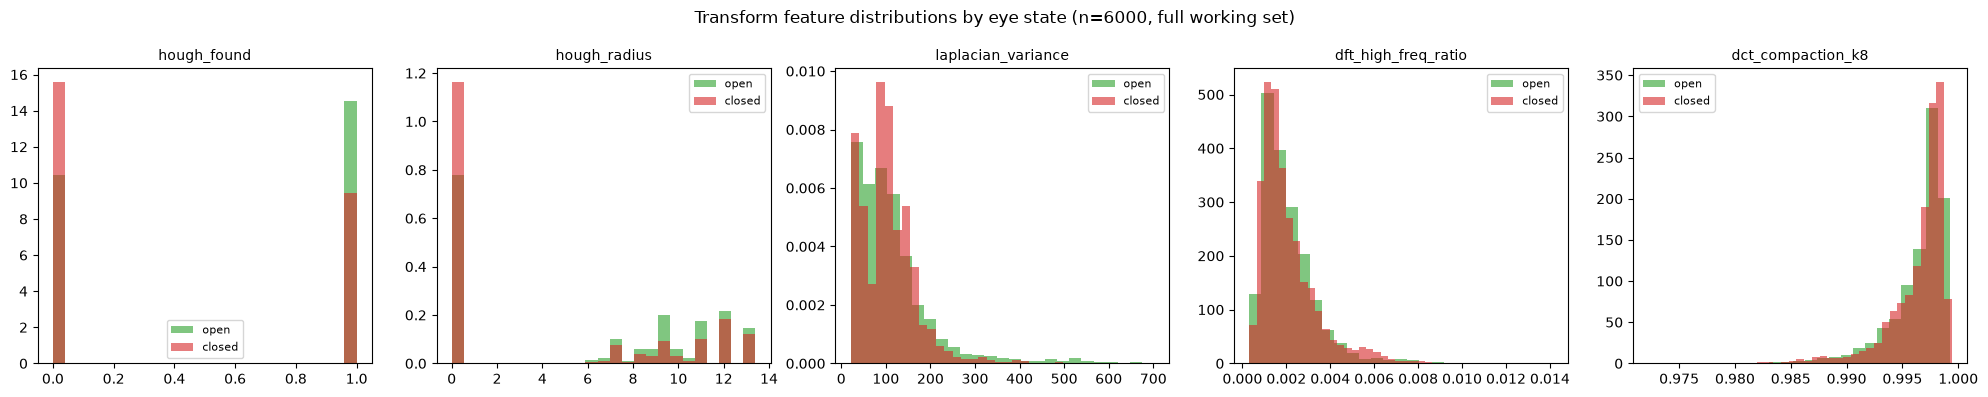

Full working set (n=6000): hough detection rate open=0.582, closed=0.377, gap=0.205


In [10]:
feat_path = REPO_ROOT / "data" / "features" / "transform_features.csv"
with open(feat_path, newline="") as f:
    feat_rows = list(csv.DictReader(f))
print(f"{len(feat_rows)} feature rows loaded from {feat_path.relative_to(REPO_ROOT)}")

def col(name, cast=float):
    return {
        "open": [cast(r[name]) for r in feat_rows if r["eye_state"] == "1"],
        "closed": [cast(r[name]) for r in feat_rows if r["eye_state"] == "0"],
    }

top_features = ["hough_found", "hough_radius", "laplacian_variance", "dft_high_freq_ratio", "dct_compaction_k8"]
fig, axes = plt.subplots(1, len(top_features), figsize=(4 * len(top_features), 4))

for ax, feat in zip(axes, top_features):
    vals = col(feat)
    ax.hist(vals["open"], bins=25, alpha=0.6, label="open", color="tab:green", density=True)
    ax.hist(vals["closed"], bins=25, alpha=0.6, label="closed", color="tab:red", density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("Transform feature distributions by eye state (n=6000, full working set)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "week5_feature_separability.png", dpi=150, bbox_inches="tight")
plt.show()

hough_found_full = col("hough_found", int)
print(f"Full working set (n={len(feat_rows)}): "
      f"hough detection rate open={np.mean(hough_found_full['open']):.3f}, "
      f"closed={np.mean(hough_found_full['closed']):.3f}, "
      f"gap={np.mean(hough_found_full['open']) - np.mean(hough_found_full['closed']):.3f}")

## Summary

- **DFT**: log-magnitude spectrum visualized open-vs-closed and
  sharp-vs-blurred; high-frequency energy ratio (radius=8 px) and an
  8-bin radial energy profile extracted as features.
- **DCT**: energy-compaction curve confirms a handful of low-frequency
  coefficients capture almost all crop energy — reused directly in Week 8.
- **Blur metric**: classical Laplacian variance beats the DFT-based ratio
  at separating sharp from synthetically-blurred crops (AUC numbers in
  Section 4) — kept both, Laplacian variance as the primary blur feature.
- **Hough circle (headline)**: iris-circle detection rate is
  meaningfully higher on open eyes than closed eyes (Section 8) — "not
  found" is itself informative, not a failure, exactly as hypothesized.
- Full 6,000-row feature table: `data/features/transform_features.csv`.
  Condensed report with all chosen parameters and honest limitations:
  `docs/week5_transforms.md`.